# Pipeline 6: Safehouse Performance

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

We combine a **transparent composite score** from monthly KPIs with a **forecast model** for next-month **incident count** to support operational learning across sites.

**What this notebook delivers**
- Z-score composite (education, health, services) minus incident penalty
- Baseline + Ridge + RF for **next-month incidents** (grouped by safehouse)
- PostgreSQL table for program director dashboard

### Pipeline strength tier
**Secondary / exploratory pipeline:** Outputs are best for **learning and discussion**, not pay-for-performance rankings, until case-mix adjustment and more history are available. **Caseload severity differs by site**—interpret ranks cautiously.

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
Leadership lacks a **repeatable** way to compare month-to-month operational signals across safehouses without relying on anecdotes alone.

### Stakeholders
| **Program director** | Supervision & support |
| **Site leads** | Peer learning |
| **Board** | High-level trends (aggregated) |

### Why this matters
Identifying **outlier months** early can trigger support (staffing, training) before crises compound.

### Predictive goal (what we forecast or score)
**Regression:** forecast **next month `incident_count`** from lagged KPIs (RF primary for scoring).

### Explanatory goal (what we want to understand)
**Ridge coefficients** on lagged features show which **lagged** metrics align with more/fewer incidents (associational).

### Why predictive and explanatory are different
Composite score is **descriptive** for dashboards; RF focuses on **predictive accuracy** for early warning.

### Decision this work supports
**Which sites get a program-office deep-dive this month** (never automatic punishment).

### Limitations (preview)
No resident-level risk adjustment in composite; small N of sites.

---


## Data Validity & Leakage Check

### How the target is defined
**Composite:** row-level z-mix of education/health/services minus incident z. **Supervised target:** `incident_count` at month *t*.

### What information is allowed at prediction time
**Lagged** features `L1_*` built from month *t-1* metrics only (after `dropna(subset=lag_features)`).

### Why future information does not leak into features
We do not use same-month outcomes as predictors for that month’s label in the forecasting block.

### Why the train/test approach is valid
**GroupKFold by `safehouse_id`** so the same house does not leak across train/test folds.

### Automated checks in this notebook
Verify `df2` row count > 0 after lag; print per-safehouse month coverage.

---


## 2. Data Acquisition & Preparation

**Tables:** `safehouse_monthly_metrics.csv`, `safehouses.csv`.

Numeric columns coerced; medians impute missing KPIs. **Lag-1** features via `groupby('safehouse_id').shift(1)`.

---


In [6]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [7]:
m = pd.read_csv(DATA_DIR / "safehouse_monthly_metrics.csv", parse_dates=["month_start", "month_end"])
sh = pd.read_csv(DATA_DIR / "safehouses.csv")
df = m.merge(sh[["safehouse_id", "name"]], on="safehouse_id", how="left")
num_cols = ["active_residents", "avg_education_progress", "avg_health_score", "process_recording_count", "home_visitation_count", "incident_count"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())
zparts = []
for col in ["avg_education_progress", "avg_health_score", "process_recording_count", "home_visitation_count"]:
    z = (df[col] - df[col].mean()) / (df[col].std() + 1e-9)
    zparts.append(z)
inc_z = (df["incident_count"] - df["incident_count"].mean()) / (df["incident_count"].std() + 1e-9)
df["composite_z"] = sum(zparts) / len(zparts) - 0.5 * inc_z
df2 = df.sort_values(["safehouse_id", "month_start"])
lag = df2.groupby("safehouse_id")[num_cols].shift(1)
feat = [f"L1_{k}" for k in num_cols]
df2 = df2.assign(**{f"L1_{k}": lag[k] for k in num_cols}).dropna(subset=feat)
X, y, g = df2[feat], df2["incident_count"], df2["safehouse_id"]
print("Forecasting panel rows", len(df2), "safehouses", g.nunique())


Forecasting panel rows 441 safehouses 9


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


Mean composite z by safehouse (exploratory index)
safehouse_id
1    0.268611
3    0.242422
5    0.144291
8    0.122749
4    0.056363
2    0.012135
6    0.001770
7   -0.259331
9   -0.589010
Name: composite_z, dtype: float64


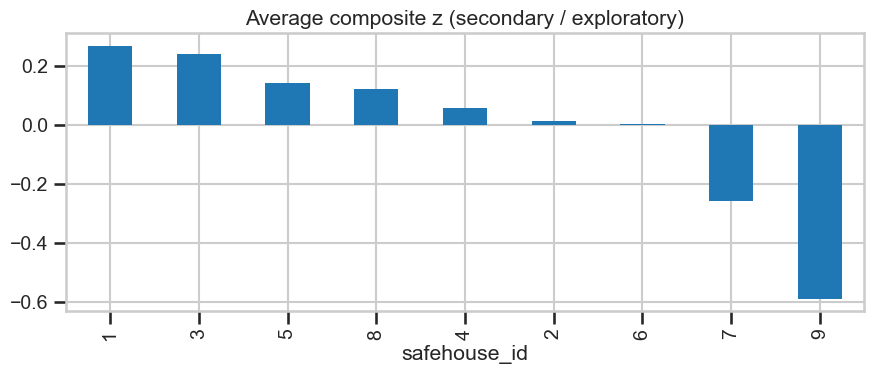

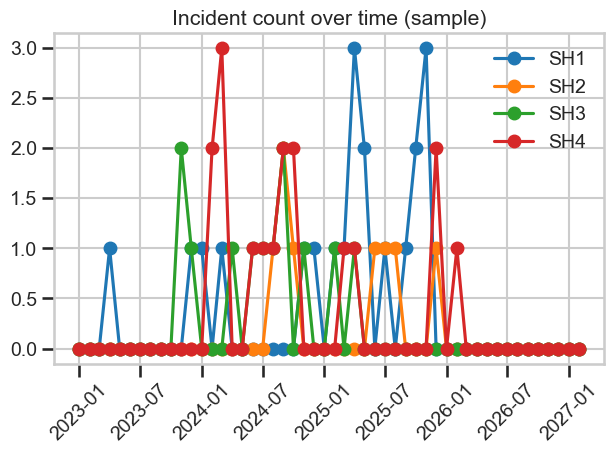

In [8]:
ranked = df.groupby("safehouse_id")["composite_z"].mean().sort_values(ascending=False)
print("Mean composite z by safehouse (exploratory index)")
print(ranked)
ranked.plot(kind="bar", figsize=(9, 4), title="Average composite z (secondary / exploratory)")
plt.tight_layout()
plt.show()
for sid in sorted(df["safehouse_id"].unique())[:4]:
    sub = df[df["safehouse_id"] == sid].sort_values("month_start")
    plt.plot(sub["month_start"], sub["incident_count"], marker="o", label=f"SH{sid}")
plt.legend()
plt.title("Incident count over time (sample)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
**All KPIs lagged one month** capture recent operational context without same-month leakage for the incident target.

### Three-model strategy
1. **Baseline — DummyRegressor (mean incidents):** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Ridge regression:** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest regressor:** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


baseline MAE 0.3697235940051433 R2 -0.011744274448912184
ridge MAE 0.31104130490681153 R2 0.1481672479122834
rf MAE 0.2959649735601126 R2 0.14516145931894622


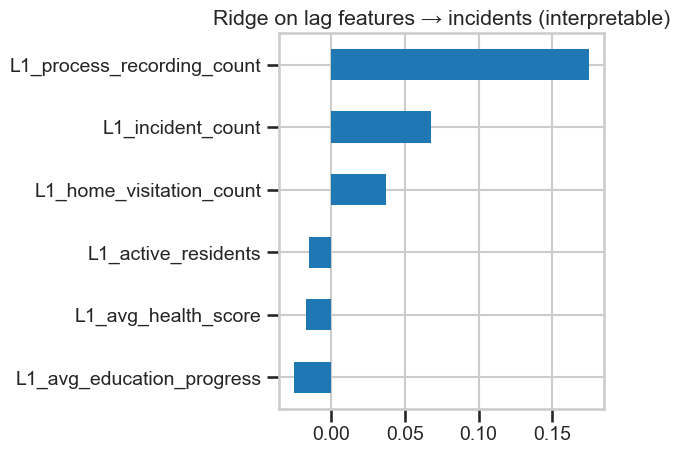

Final model for scoring: RF if it beats baseline MAE in CV; Ridge for coefficient stories.


In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def pipe(model):
    return Pipeline([("s", StandardScaler()), ("m", model)])

gkf = GroupKFold(4)
for name, model in [("baseline", DummyRegressor(strategy="mean")), ("ridge", Ridge(1.0)), ("rf", RandomForestRegressor(150, max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]:
    sc = cross_validate(pipe(model), X, y, cv=gkf, groups=g, scoring={"mae": "neg_mean_absolute_error", "r2": "r2"}, n_jobs=-1)
    print(name, "MAE", -sc["test_mae"].mean(), "R2", sc["test_r2"].mean())
rf = pipe(RandomForestRegressor(150, max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))
rf.fit(X, y)
ridge_explain = pipe(Ridge(1.0))
ridge_explain.fit(X, y)
coef = pd.Series(ridge_explain.named_steps["m"].coef_, index=feat).sort_values()
coef.plot(kind="barh", title="Ridge on lag features → incidents (interpretable)")
plt.tight_layout()
plt.show()
print("Final model for scoring: RF if it beats baseline MAE in CV; Ridge for coefficient stories.")


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
**Composite z** is a weighted narrative index for dashboards; **RF forecast** flags months where incidents may spike vs recent lag pattern.

### How reliable is this for real decisions?
Incident counts are **sparse**—expect modest R². Use as **triage**, not precision scheduling.

### What should the organization do differently?
Pair flags with **qualitative** site context; fund **support visits**, not blame.

### What decision does this directly support?
**Program office site visits** and **resource reallocation** conversations.

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  Unneeded intensive visit → staff time cost.
- **False negatives (model said “low concern” but something important happened):**  
  Miss a brewing crisis → safety risk; keep **non-model** reporting channels mandatory.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Lagged incidents often predict future incidents (persistence).

### Why these are not proven causal
Operational changes were not randomized.

### Honest limitations
Nine sites; heterogeneous missions.

---


## Key Findings

- Composite is **transparent**; forecasting is **probabilistic** and weak at small N.
- Always read **secondary tier** disclaimer to stakeholders.
- Ridge shows **which lagged signals** align with incidents in linear approximation.

---


## Recommended Actions

- Add **case-mix** variables when available before using ranks in HR contexts.
- Log **site narratives** alongside scores each month.

---


## 7. Deployment Plan

### What triggers scoring
**Monthly** ETL after `safehouse_monthly_metrics` refresh.

### Where results appear in the .NET application
**.NET Program Portal → Safehouse dashboard** tab: table + sparklines; filter `predicted_incidents_next_month > site_p90`.

### Who uses the output and how
| **Program director** | Oversight |
| **Regional supervisor** | Visits |

### PostgreSQL table schema

```sql
CREATE TABLE safehouse_performance_scores (
  id BIGSERIAL PRIMARY KEY,
  safehouse_id INTEGER NOT NULL,
  month_start DATE NOT NULL,
  composite_z DOUBLE PRECISION NOT NULL,
  predicted_next_month_incidents DOUBLE PRECISION,
  model_version VARCHAR(40) NOT NULL,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (safehouse_id, month_start, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO safehouse_performance_scores (safehouse_id, month_start, composite_z, predicted_next_month_incidents, model_version)
VALUES (3, DATE '2026-03-01', 0.12, 1.4, 'safehouse_v2')
ON CONFLICT (safehouse_id, month_start, model_version)
DO UPDATE SET composite_z = EXCLUDED.composite_z, predicted_next_month_incidents = EXCLUDED.predicted_next_month_incidents, scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.

Batch computes composite from raw metrics, then `rf.predict` on latest lag row per site.

---


In [10]:
from joblib import dump
dump(rf, OUTPUT_DIR / "safehouse_incident_rf_v2.joblib")
print("Saved RF forecaster")


Saved RF forecaster
